In [399]:
import os
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [400]:
class LOLDataset(Dataset):

    def __init__(self, image_dir):

        self.image_dir = image_dir

        self.image_names = os.listdir(image_dir)

    def __len__(self):

        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = image.astype(np.float32) / 255.0

        image = torch.tensor(image)

        image = image.permute(2,0,1)

        return image

In [401]:
train_dataset = LOLDataset(
    "LOL-v2/Synthetic/Train/Low"
)

In [402]:
print(len(train_dataset))

900


In [403]:
train_loader = DataLoader(

    train_dataset,

    batch_size=4,

    shuffle=True
)

In [404]:
batch = next(iter(train_loader))

print(batch.shape)

torch.Size([4, 3, 384, 384])


In [405]:
class ZeroDCE(nn.Module):

    def __init__(self):

        super().__init__()

        self.relu = nn.ReLU(inplace=True)

        self.e_conv1 = nn.Conv2d(3,32,3,1,1)

        self.e_conv2 = nn.Conv2d(32,32,3,1,1)

        self.e_conv3 = nn.Conv2d(32,32,3,1,1)

        self.e_conv4 = nn.Conv2d(32,32,3,1,1)

        self.e_conv5 = nn.Conv2d(32,32,3,1,1)

        self.e_conv6 = nn.Conv2d(32,32,3,1,1)

        self.e_conv7 = nn.Conv2d(32,24,3,1,1)

    def forward(self, x):

        x1 = self.relu(self.e_conv1(x))

        x2 = self.relu(self.e_conv2(x1))

        x3 = self.relu(self.e_conv3(x2))

        x4 = self.relu(self.e_conv4(x3))

        x5 = self.relu(self.e_conv5(x4))

        x6 = self.relu(self.e_conv6(x5))

        x_r = torch.tanh(
            self.e_conv7(x6)
        )

        r1,r2,r3,r4,r5,r6,r7,r8 = torch.split(
            x_r,
            3,
            dim=1
        )    

        x = x + r1*(x*x - x)

        x = x + r2*(x*x - x)

        x = x + r3*(x*x - x)

        x = x + r4*(x*x - x)

        x = x + r5*(x*x - x)

        x = x + r6*(x*x - x)

        x = x + r7*(x*x - x)

        enhanced = x + r8*(x*x - x)

        return enhanced

In [406]:
model = ZeroDCE()

In [407]:
sample = batch[:1]

output = model(sample)

print(output.shape)

torch.Size([1, 3, 384, 384])


In [408]:
class SpatialLoss(nn.Module):

    def __init__(self):

        super().__init__()

    def forward(self,
                original,
                enhanced):

        return torch.mean(
            (original - enhanced)**2
        )

In [409]:
class ExposureLoss(nn.Module):

    def __init__(self,
                 mean_val=0.6):

        super().__init__()

        self.mean_val = mean_val

    def forward(self, image):

        mean = torch.mean(image)

        return (mean - self.mean_val)**2

In [410]:
class ColorLoss(nn.Module):

    def __init__(self):

        super().__init__()

    def forward(self, image):

        r,g,b = torch.mean(
            image,
            dim=[2,3]
        ).split(1, dim=1)

        loss = (
            (r-g)**2 +
            (r-b)**2 +
            (g-b)**2
        )

        return torch.mean(loss)

In [411]:
spatial_loss = SpatialLoss()

exposure_loss = ExposureLoss()

color_loss = ColorLoss()

In [412]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-4
)

In [413]:
epochs = 5

In [414]:
# for epoch in range(epochs):

#     epoch_loss = 0

#     for batch in train_loader:

#         enhanced = model(batch)

#         loss_spa = spatial_loss(
#             batch,
#             enhanced
#         )

#         loss_exp = exposure_loss(
#             enhanced
#         )

#         loss_col = color_loss(
#             enhanced
#         )

#         total_loss = (
#             loss_spa +
#             loss_exp +
#             loss_col
#         )

#         optimizer.zero_grad()

#         total_loss.backward()

#         optimizer.step()

#         epoch_loss += total_loss.item()

#     print(
#         f"Epoch {epoch+1}, Loss: {epoch_loss}"
#     )

In [415]:
path = "output/weights/zero_dce.pth"

if os.path.exists(path):
    model.load_state_dict(torch.load(path))
else:
    print(f"Model file not found: {path}")

Model file not found: output/weights/zero_dce.pth


In [416]:
model.eval()

ZeroDCE(
  (relu): ReLU(inplace=True)
  (e_conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e_conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e_conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e_conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e_conv5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e_conv6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e_conv7): Conv2d(32, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [417]:
with torch.no_grad():

    sample = batch[:1]

    enhanced = model(sample)

In [418]:
enhanced_img = enhanced[0]

enhanced_img = enhanced_img.permute(
    1,2,0
)

enhanced_img = enhanced_img.numpy()

enhanced_img = np.clip(
    enhanced_img,
    0,
    1
)

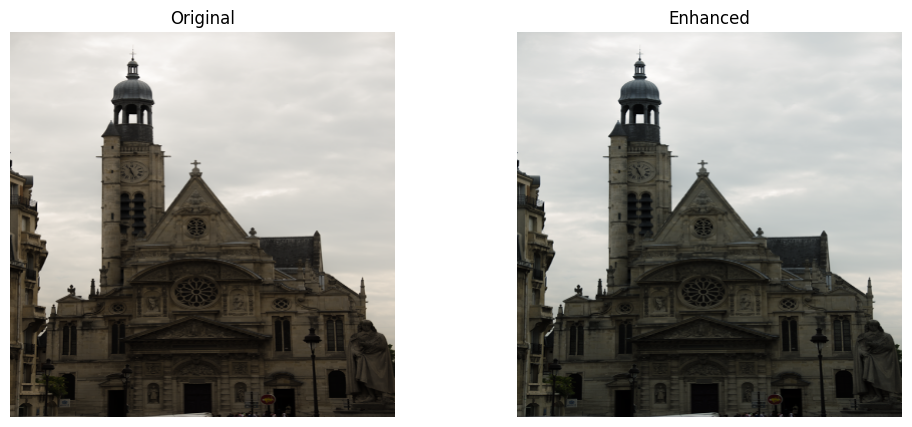

In [419]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.imshow(
    sample[0].permute(1,2,0)
)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(enhanced_img)

plt.title("Enhanced")

plt.axis("off")

plt.show()

In [420]:
start = time.time()

with torch.no_grad():

    enhanced = model(sample)

end = time.time()

print(
    "Inference Time:",
    end-start
)

Inference Time: 0.07590699195861816
